In [45]:
# ============================================================
# AUTOGLUON - CICIoT2023
# Cenário Binário: Benign x Malicious
# Dataset: C:\Dataset\CSV
# ============================================================

# Se ainda não tiver instalado, execute uma vez:
# !pip install -U autogluon

import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from autogluon.tabular import TabularDataset, TabularPredictor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

In [46]:
# ============================================================
# 1. Configurações principais
# ============================================================

DATASET_DIR = Path(r"C:\Dataset\CSV")
RESULTS_DIR = Path(r"C:\Dataset\Resultados\AutoGluon_Binario")
MODEL_DIR = RESULTS_DIR / "modelo_autogluon_binario"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_FINAL = "label_binary"

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Use None para treinar com todo o dataset.
# Para evitar erro de memória, pode usar, por exemplo: 100000
MAX_ROWS_PER_CLASS = 200000

# Tempo máximo de treinamento em segundos.
# Exemplo: 3600 = 1 hora
# Use None para deixar o AutoGluon decidir.
TIME_LIMIT = 3600 

CHUNKSIZE = 200000


# ============================================================
# 2. Localizar arquivos CSV
# ============================================================

# Procurar todos os arquivos .csv
csv_files = glob.glob(os.path.join(DATASET_DIR, "*.csv"))

print(f"Total de arquivos CSV encontrados: {len(csv_files)}")

if len(csv_files) == 0:
    raise FileNotFoundError(f"Nenhum arquivo CSV encontrado em: {DATASET_DIR}")


# ============================================================
# 3. Função para detectar coluna de rótulo
# ============================================================

def detectar_coluna_rotulo(columns):
    candidatos = [
        "label", "Label",
        "Attack", "attack",
        "Class", "class",
        "category", "Category",
        "label_multiclass",
        "label_grouped",
        "label_binary"
    ]

    for col in candidatos:
        if col in columns:
            return col

    # Se não encontrar coluna de rótulo, retorna None
    return None

Total de arquivos CSV encontrados: 372


In [47]:
# ============================================================
# 4. Função para converter rótulos em Benign/Malicious
# ============================================================

def converter_para_binario(valor):
    valor = str(valor).strip().lower()

    if "benign" in valor:
        return "Benign"
    else:
        return "Malicious"


# ============================================================
# 5. Carregar dataset em chunks
# ============================================================

dados = []
contagem = {"Benign": 0, "Malicious": 0}

parar_leitura = False

for file in csv_files:
    nome_arquivo = os.path.basename(file)
    nome_arquivo_lower = nome_arquivo.lower()

    print(f"\nLendo arquivo: {nome_arquivo}")

    # Define a classe com base no nome do arquivo
    # Exemplo:
    # BenignTraffic.csv      -> Benign
    # DoS-TCP_Flood4.csv     -> Malicious
    # DDoS-ICMP_Flood.csv    -> Malicious

    classe_arquivo = converter_para_binario(nome_arquivo)

    try:
        for chunk in pd.read_csv(file, chunksize=CHUNKSIZE, low_memory=False):

            # Padronizar nomes das colunas
            chunk.columns = chunk.columns.astype(str).str.strip()

            # Tenta detectar uma coluna de rótulo no CSV
            label_original = detectar_coluna_rotulo(chunk.columns)

            if label_original is not None:
                # Se existir coluna de rótulo, usa a coluna
                chunk[LABEL_FINAL] = chunk[label_original].apply(converter_para_binario)
            else:
                # Se não existir coluna de rótulo, usa o nome do arquivo
                chunk[LABEL_FINAL] = classe_arquivo

            # Remover colunas de rótulo antigas para evitar vazamento de informação
            colunas_remover = [
                "label", "Label",
                "Attack", "attack",
                "Class", "class",
                "category", "Category",
                "label_multiclass",
                "label_grouped",
                "source_file",
                "Source_File",
                "filename",
                "Filename"
            ]

            colunas_remover = [
                col for col in colunas_remover
                if col in chunk.columns and col != LABEL_FINAL
            ]

            chunk = chunk.drop(columns=colunas_remover, errors="ignore")

            # Limitar quantidade por classe, se definido
            if MAX_ROWS_PER_CLASS is not None:
                partes = []

                for classe in ["Benign", "Malicious"]:
                    restante = MAX_ROWS_PER_CLASS - contagem[classe]

                    if restante <= 0:
                        continue

                    sub = chunk[chunk[LABEL_FINAL] == classe]

                    if len(sub) > restante:
                        sub = sub.sample(
                            n=restante,
                            random_state=RANDOM_STATE
                        )

                    contagem[classe] += len(sub)
                    partes.append(sub)

                if len(partes) > 0:
                    dados.append(pd.concat(partes, ignore_index=True))

                print("Contagem parcial:", contagem)

                if all(contagem[c] >= MAX_ROWS_PER_CLASS for c in contagem):
                    parar_leitura = True
                    break

            else:
                dados.append(chunk)

        if parar_leitura:
            break

    except Exception as e:
        print(f"Erro ao ler {file}: {e}")


if len(dados) == 0:
    raise ValueError("Nenhum dado foi carregado. Verifique os arquivos CSV.")


df = pd.concat(dados, ignore_index=True)

print("\nDataset carregado com sucesso!")
print("Shape inicial:", df.shape)


print("\nDistribuição das classes:")
print(df[LABEL_FINAL].value_counts())



Lendo arquivo: Backdoor_Malware.pcap.csv
Contagem parcial: {'Benign': 0, 'Malicious': 3218}

Lendo arquivo: BenignTraffic.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}

Lendo arquivo: BenignTraffic1.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}

Lendo arquivo: BenignTraffic2.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}

Lendo arquivo: BenignTraffic3.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 3218}

Lendo arquivo: BrowserHijacking.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 9077}

Lendo arquivo: CommandInjection.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 14486}

Lendo arquivo: DDoS-ACK_Fragmentation.pcap.csv
Contagem parcial: {'Benign': 200000, 'Malicious': 39576}

Lendo arquivo: DDoS-ACK_Fragmentation1.pcap.csv
Conta

In [48]:
# ============================================================
# 6. Tratamento do dataset
# ============================================================

# Remover colunas duplicadas
df = df.loc[:, ~df.columns.duplicated()]

# Remover linhas sem rótulo
df = df.dropna(subset=[LABEL_FINAL])

# Substituir valores infinitos por NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Remover colunas totalmente vazias
df = df.dropna(axis=1, how="all")

# Remover colunas constantes, exceto o rótulo
feature_cols = [col for col in df.columns if col != LABEL_FINAL]

const_cols = [
    col for col in feature_cols
    if df[col].nunique(dropna=False) <= 1
]

df = df.drop(columns=const_cols, errors="ignore")

print("\nShape após limpeza:", df.shape)

print("\nDistribuição das classes:")
print(df[LABEL_FINAL].value_counts())


# ============================================================
# 7. Verificar se existem as duas classes
# ============================================================

classes = df[LABEL_FINAL].unique()

if len(classes) < 2:
    raise ValueError(
        f"O dataset contém apenas uma classe: {classes}. "
        "Para classificação binária, é necessário ter Benign e Malicious."
    )


# ============================================================
# 8. Dividir em treino e teste
# ============================================================

train_data, test_data = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[LABEL_FINAL]
)

train_data = TabularDataset(train_data)
test_data = TabularDataset(test_data)

print("\nTamanho do conjunto de treino:", train_data.shape)
print("Tamanho do conjunto de teste :", test_data.shape)

print("\nClasses no treino:")
print(train_data[LABEL_FINAL].value_counts())

print("\nClasses no teste:")
print(test_data[LABEL_FINAL].value_counts())



Shape após limpeza: (400000, 40)

Distribuição das classes:
label_binary
Malicious    200000
Benign       200000
Name: count, dtype: int64

Tamanho do conjunto de treino: (320000, 40)
Tamanho do conjunto de teste : (80000, 40)

Classes no treino:
label_binary
Malicious    160000
Benign       160000
Name: count, dtype: int64

Classes no teste:
label_binary
Malicious    40000
Benign       40000
Name: count, dtype: int64


In [49]:
# ============================================================
# 9. Treinar modelo AutoGluon
# ============================================================

predictor = TabularPredictor(
    label=LABEL_FINAL,
    path=str(MODEL_DIR),
    problem_type="binary",
    eval_metric="balanced_accuracy",
    verbosity=2
).fit(
    train_data=train_data,
    presets="medium_quality_faster_train",
    time_limit=TIME_LIMIT
)


# ============================================================
# 10. Fazer predições
# ============================================================

X_test = test_data.drop(columns=[LABEL_FINAL])
y_test = test_data[LABEL_FINAL]

y_pred = predictor.predict(X_test)

print("\nPrimeiras predições:")
print(y_pred.head())


# ============================================================
# 11. Avaliação pelo AutoGluon
# ============================================================

print("\n====================================================")
print("AVALIAÇÃO AUTOGLUON")
print("====================================================")

avaliacao_autogluon = predictor.evaluate(test_data)
print(avaliacao_autogluon)


Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.21 GB / 15.88 GB (39.1%)
Disk Space Avail:   195.08 GB / 930.66 GB (21.0%)
Presets specified: ['medium_quality_faster_train']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 3600s
AutoGluon will save models to "C:\Dataset\Resultados\AutoGluon_Binario\modelo_autogluon_binario"
Train Data Rows:    320000
Train Data Columns: 39
Label Column:       label_binary
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = Malicious, class 0 = Benign
	Note: For your binary classification, AutoG


Primeiras predições:
379148    Malicious
122102       Benign
132283       Benign
321494    Malicious
220283    Malicious
Name: label_binary, dtype: object

AVALIAÇÃO AUTOGLUON
{'balanced_accuracy': np.float64(0.977075), 'accuracy': 0.977075, 'mcc': 0.9544852024760393, 'roc_auc': np.float64(0.9967366671875), 'f1': 0.976767164935394, 'precision': 0.9900616332819723, 'recall': 0.963825}


In [53]:
# ============================================================
# 12. Métricas detalhadas com Scikit-learn
# ============================================================

labels_order = ["Benign", "Malicious"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_order
)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    pos_label="Malicious",
    zero_division=0
)
recall = recall_score(
    y_test,
    y_pred,
    pos_label="Malicious",
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Malicious",
    zero_division=0
)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
mcc = matthews_corrcoef(y_test, y_pred)

false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

roc_auc = np.nan
avg_precision = np.nan

try:
    y_proba = predictor.predict_proba(X_test)

    if "Malicious" in y_proba.columns:
        y_score = y_proba["Malicious"]
        y_test_bin = y_test.map({"Benign": 0, "Malicious": 1})

        roc_auc = roc_auc_score(y_test_bin, y_score)
        avg_precision = average_precision_score(y_test_bin, y_score)

except Exception as e:
    print(f"Não foi possível calcular ROC-AUC/Average Precision: {e}")


print("\n====================================================")
print("RESULTADOS - AUTOGLUON - CLASSIFICAÇÃO BINÁRIA")
print("====================================================")
print(f"Accuracy              : {accuracy:.6f}")
print(f"Balanced Accuracy     : {balanced_acc:.6f}")
print(f"Precision             : {precision:.6f}")
print(f"Recall / Sensibilidade: {recall:.6f}")
print(f"F1-score              : {f1:.6f}")
print(f"Specificity           : {specificity:.6f}")
print(f"ROC-AUC               : {roc_auc:.6f}")
print(f"Average Precision     : {avg_precision:.6f}")
print(f"MCC                   : {mcc:.6f}")
print(f"False Positive Rate   : {false_positive_rate:.6f}")
print(f"False Negative Rate   : {false_negative_rate:.6f}")



RESULTADOS - AUTOGLUON - CLASSIFICAÇÃO BINÁRIA
Accuracy              : 0.977075
Balanced Accuracy     : 0.977075
Precision             : 0.990062
Recall / Sensibilidade: 0.963825
F1-score              : 0.976767
Specificity           : 0.990325
ROC-AUC               : 0.996737
Average Precision     : 0.997222
MCC                   : 0.954485
False Positive Rate   : 0.009675
False Negative Rate   : 0.036175



RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98     40000
   Malicious       0.99      0.96      0.98     40000

    accuracy                           0.98     80000
   macro avg       0.98      0.98      0.98     80000
weighted avg       0.98      0.98      0.98     80000


MATRIZ DE CONFUSÃO
[[39613   387]
 [ 1447 38553]]


<Figure size 600x500 with 0 Axes>

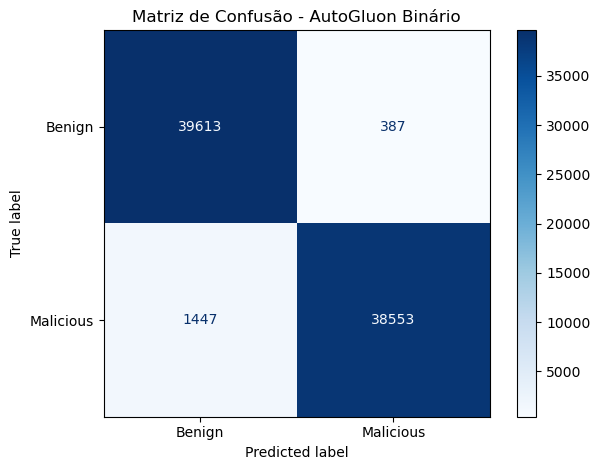


Matriz de confusão salva em: C:\Dataset\Resultados\AutoGluon_Binario\matriz_confusao_autogluon_binario.png

LEADERBOARD - AUTOGLUON
                 model  score_test  score_val        eval_metric  \
0             LightGBM    0.978250   0.980313  balanced_accuracy   
1     RandomForestEntr    0.977350   0.978750  balanced_accuracy   
2     RandomForestGini    0.977313   0.980000  balanced_accuracy   
3              XGBoost    0.977288   0.979688  balanced_accuracy   
4  WeightedEnsemble_L2    0.977075   0.982500  balanced_accuracy   
5           LightGBMXT    0.976787   0.978438  balanced_accuracy   
6             CatBoost    0.976325   0.978750  balanced_accuracy   
7       ExtraTreesEntr    0.975662   0.977500  balanced_accuracy   
8       NeuralNetTorch    0.975350   0.980625  balanced_accuracy   
9       ExtraTreesGini    0.975287   0.977187  balanced_accuracy   

   pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  \
0        0.241101       0.014800     4.71795

In [54]:
# ============================================================
# 13. Relatório de classificação
# ============================================================

print("\n====================================================")
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("====================================================")

report_text = classification_report(
    y_test,
    y_pred,
    labels=labels_order,
    zero_division=0
)

print(report_text)

report_dict = classification_report(
    y_test,
    y_pred,
    labels=labels_order,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()


# ============================================================
# 14. Matriz de confusão
# ============================================================

print("\n====================================================")
print("MATRIZ DE CONFUSÃO")
print("====================================================")
print(cm)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_order
)
disp.plot(values_format="d", cmap="Blues")
plt.title("Matriz de Confusão - AutoGluon Binário")
plt.tight_layout()

cm_path = RESULTS_DIR / "matriz_confusao_autogluon_binario.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nMatriz de confusão salva em: {cm_path}")


# ============================================================
# 15. Leaderboard dos modelos
# ============================================================

leaderboard = predictor.leaderboard(test_data, silent=True)

print("\n====================================================")
print("LEADERBOARD - AUTOGLUON")
print("====================================================")
print(leaderboard)


# ============================================================
# 16. Salvar resultados em CSV
# ============================================================

metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall / Sensibilidade",
        "F1-score",
        "Specificity",
        "ROC-AUC",
        "Average Precision",
        "MCC",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Valor": [
        accuracy,
        balanced_acc,
        precision,
        recall,
        f1,
        specificity,
        roc_auc,
        avg_precision,
        mcc,
        false_positive_rate,
        false_negative_rate
    ]
})

metrics_path = RESULTS_DIR / "metricas_autogluon_binario.csv"
report_path = RESULTS_DIR / "classification_report_autogluon_binario.csv"
leaderboard_path = RESULTS_DIR / "leaderboard_autogluon_binario.csv"

metrics_df.to_csv(metrics_path, index=False)
report_df.to_csv(report_path)
leaderboard.to_csv(leaderboard_path, index=False)

print("\nArquivos CSV salvos:")
print(metrics_path)
print(report_path)
print(leaderboard_path)

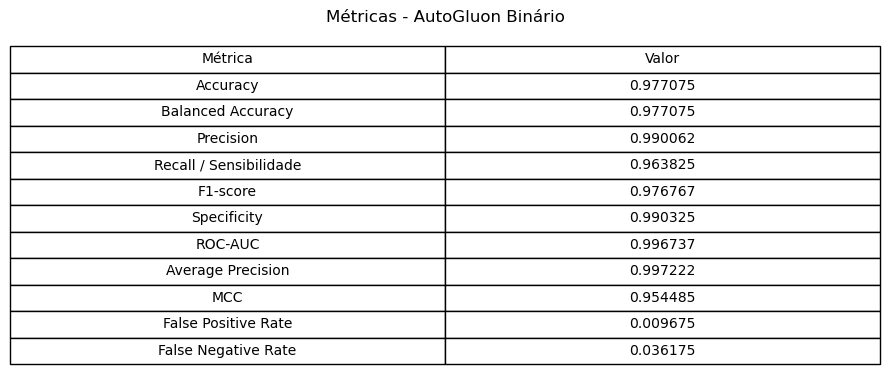

Métricas salvas em PNG: C:\Dataset\Resultados\AutoGluon_Binario\metricas_autogluon_binario.png


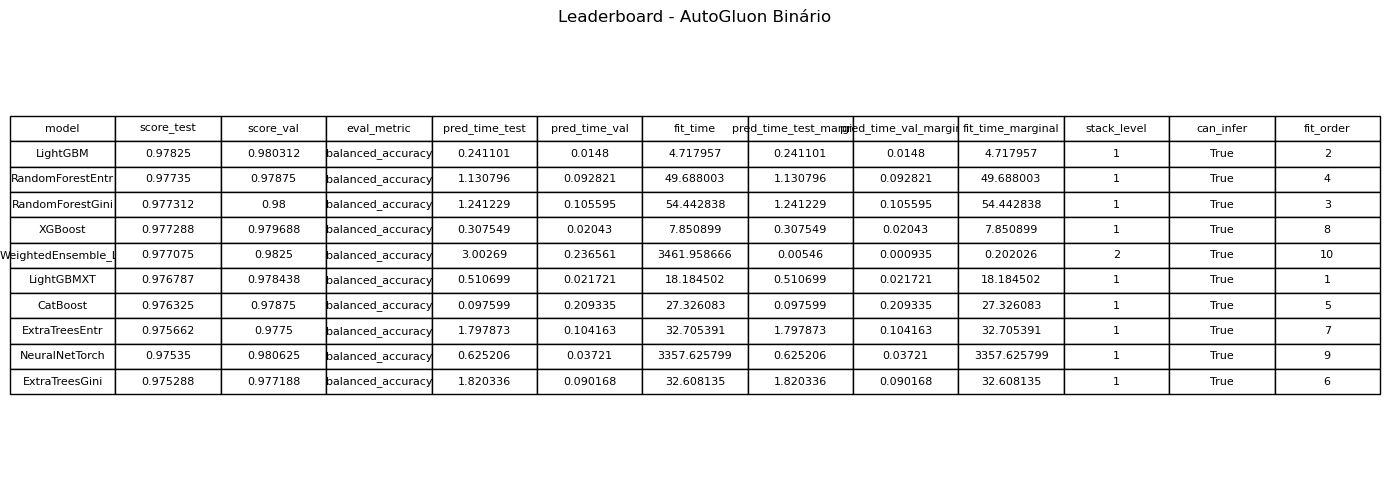

Leaderboard salvo em PNG: C:\Dataset\Resultados\AutoGluon_Binario\leaderboard_autogluon_binario.png

PROCESSO FINALIZADO COM SUCESSO
Modelo salvo em     : C:\Dataset\Resultados\AutoGluon_Binario\modelo_autogluon_binario
Resultados salvos em: C:\Dataset\Resultados\AutoGluon_Binario


In [55]:
# ============================================================
# 17. Salvar métricas como imagem PNG
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off")

metrics_table = metrics_df.copy()
metrics_table["Valor"] = metrics_table["Valor"].apply(
    lambda x: f"{x:.6f}" if pd.notna(x) else "NaN"
)

table = ax.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.title("Métricas - AutoGluon Binário", fontsize=12)
plt.tight_layout()

metrics_png_path = RESULTS_DIR / "metricas_autogluon_binario.png"
plt.savefig(metrics_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Métricas salvas em PNG: {metrics_png_path}")


# ============================================================
# 18. Salvar leaderboard como imagem PNG
# ============================================================

leaderboard_view = leaderboard.head(20).copy()

for col in leaderboard_view.columns:
    if pd.api.types.is_numeric_dtype(leaderboard_view[col]):
        leaderboard_view[col] = leaderboard_view[col].round(6)

fig, ax = plt.subplots(figsize=(14, max(5, 0.45 * len(leaderboard_view))))
ax.axis("off")

table = ax.table(
    cellText=leaderboard_view.values,
    colLabels=leaderboard_view.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

plt.title("Leaderboard - AutoGluon Binário", fontsize=12)
plt.tight_layout()

leaderboard_png_path = RESULTS_DIR / "leaderboard_autogluon_binario.png"
plt.savefig(leaderboard_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Leaderboard salvo em PNG: {leaderboard_png_path}")


# ============================================================
# 19. Finalização
# ============================================================

print("\n====================================================")
print("PROCESSO FINALIZADO COM SUCESSO")
print("====================================================")
print(f"Modelo salvo em     : {MODEL_DIR}")
print(f"Resultados salvos em: {RESULTS_DIR}")